## World Bank Indicators Visualization Exploration:

### GDP per capita, fertility rate, and life expectancy as correlated development indicators

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [12]:
import pandas as pd

# Reading CSV data, and skipping rows of metadata
gdp = pd.read_csv("WB_GDP_per_capita.csv", skiprows=4)
fert = pd.read_csv("WB_Fertility_Rate.csv", skiprows=4)
life = pd.read_csv("WB_Life_Expectancy.csv", skiprows=4)

# Extract only relevant columns for 2021
gdp_2021 = gdp[["Country Name", "Country Code", "2021"]].rename(columns={"2021": "gdp_per_capita"})
fert_2021 = fert[["Country Name", "Country Code", "2021"]].rename(columns={"2021": "fertility_rate"})
life_2021 = life[["Country Name", "Country Code", "2021"]].rename(columns={"2021": "life_expectancy"})

# Merge into one dataframe
df = (
    gdp_2021
    .merge(fert_2021, on=["Country Name", "Country Code"])
    .merge(life_2021, on=["Country Name", "Country Code"])
)

# Droping missing rows
df = df.dropna()

df.head()

,Country Name,Country Code,gdp_per_capita,fertility_rate,life_expectancy
0,Aruba,ABW,27200.061079,1.631000,73.655000
1,Africa Eastern and Southern,AFE,1522.393346,4.350683,62.979999
2,Afghanistan,AFG,356.496214,5.039000,60.417000
3,Africa Western and Central,AFW,1765.954788,4.637741,57.362572
4,Angola,AGO,1925.874661,5.304000,62.958000


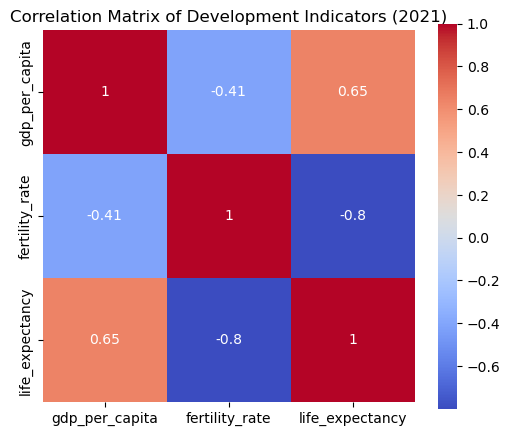

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Computing correlations
corr = df[["gdp_per_capita", "fertility_rate", "life_expectancy"]].corr()

# Plotting correlation matrix
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", square=True)
plt.title("Correlation Matrix of Development Indicators (2021)")
plt.show()


**Interpretation of Correlation Matrix**
- The correlation matrix shows a moderate negative correlation between GDP per capita and fetility rate, a strong positive correlation between life expectancy and GDP per capita, and a strong negative correlation between fertility rate and life expectancy. These relationships suggest that countries with higher income levels tend to have longer lifespans and lower fertility rates. 

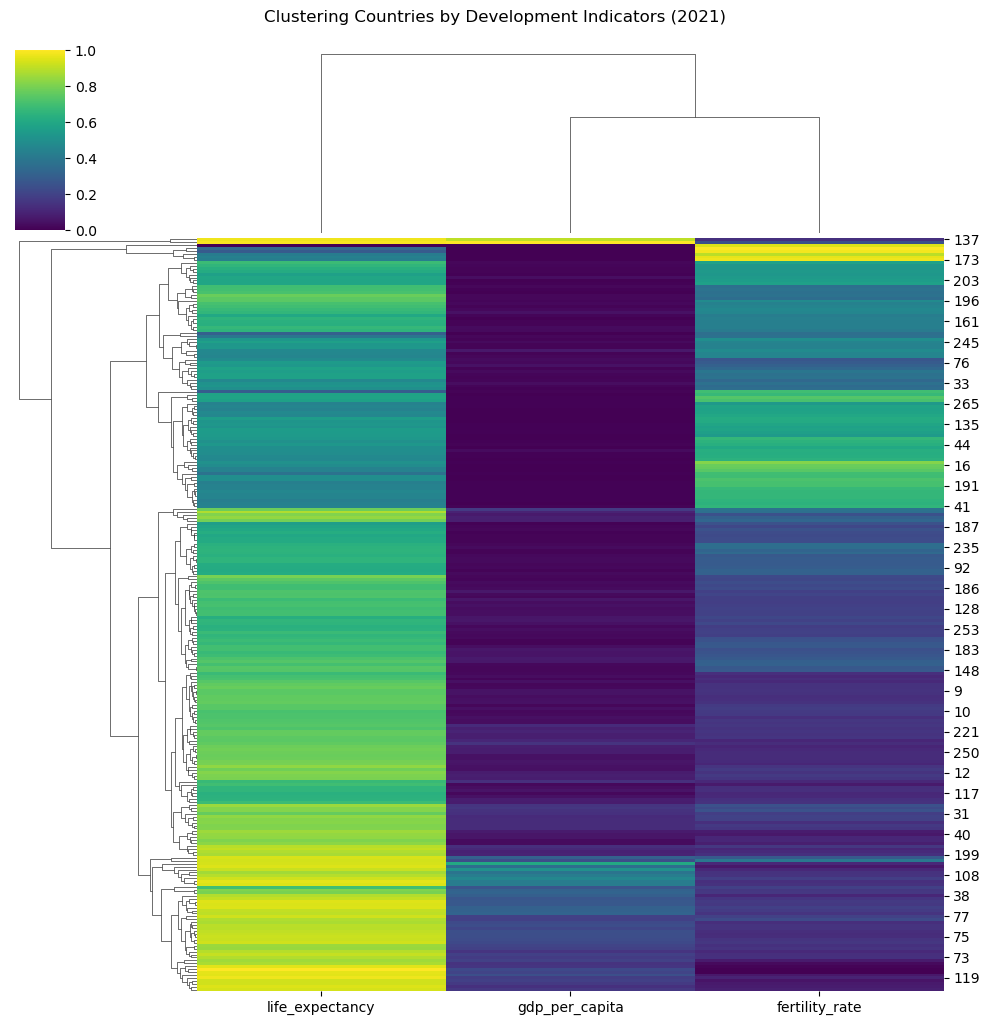

In [14]:
# Plotting cluster map of features with normalization to account for 
# each indicator's different scale
sns.clustermap(
    df[["gdp_per_capita", "fertility_rate", "life_expectancy"]],
    cmap="viridis",
    standard_scale=1,
    figsize=(10, 10)
)
plt.suptitle("Clustering Countries by Development Indicators (2021)", y=1.02)
plt.show()

**Interpretation of Clustermap**
- The hierarchical clustermap groups countries with similar development profiles, revealing a clear separation between high-income countries with higher life expectancy and lower fertility, and lower-income countries with the opposite indicator values. Although GDP per capita appears mostly low after scaling—because only a small number of countries have very high income levels—the clustering still shows that these higher-income countries concentrate together in the group with low fertility and high life expectancy.

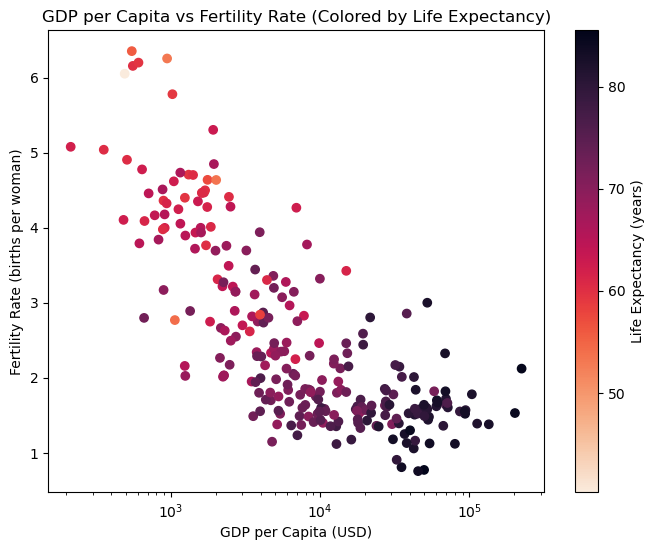

In [15]:
# Plotting scatterplot of GDP per capita vs fertility rate, 
# colored by life expectancy
plt.figure(figsize=(8,6))
plt.scatter(df["gdp_per_capita"], df["fertility_rate"], c=df["life_expectancy"], cmap="rocket_r")
plt.colorbar(label="Life Expectancy (years)")
plt.xlabel("GDP per Capita (USD)")
plt.ylabel("Fertility Rate (births per woman)")
plt.title("GDP per Capita vs Fertility Rate (Colored by Life Expectancy)")
plt.xscale("log") # using log scale to improve readability
plt.show()

**Interpretation of Scatterplot**
- The scatterplot reveals a clear inverse relationship between GDP per capita and fertility rate. The color gradient shows that countries with higher income also tend to have higher life expectancy, while countries with lower income have lower life expectancy and higher fertility rates. 

**CONCLUSION**

Using 2021 World Bank data on GDP per capita, fertility rate, and life expectancy, all three visualizations consistently show that higher-income countries tend to have longer life expectancy and lower fertility rates, while lower-income countries exhibit the opposite pattern. The correlation matrix highlights the strength and direction of these relationships, and the clustermap reveals clear groupings in which high-income, low-fertility, high-life-expectancy countries cluster together. The scatterplot further supports these findings by illustrating the inverse relationship between GDP per capita and fertility rate, as well as the tendency for higher-income countries to have higher life expectancy.